In [12]:
# import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# set up
pd.set_option('display.max_columns', None)

In [88]:
# Load data

merged = pd.read_csv('../data/processed/merged.csv')
colours = pd.read_csv('../data/processed/colours_unmatched.csv')

path = os.path.expanduser('../data/processed/bird_list.txt')

with open(path, 'r') as f:
    birds = [line.strip() for line in f]


/tmp/ipykernel_27809/2731011295.py:3: DtypeWarning: Columns (51,52,53,54,55,56,74,76) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv('../data/processed/merged.csv')


In [89]:
merged.columns.to_list()

['English Name (BirdLife > IOC > Clements>AviList)',
 'scientific_name',
 'Order_x',
 'Family IOC 15.1',
 'Genus',
 'Species',
 '2024 IUCN Red List category',
 'RR',
 'ISL',
 'RLM',
 'LAT',
 'Female MinMass',
 'Female MaxMass',
 'Male MinMass',
 'Male MaxMass',
 'Unsexed MinMass',
 'Unsexed MaxMass',
 'Average Mass',
 'NormMin',
 'Elevational Range',
 'NormMax',
 'F',
 'BM',
 'WD',
 'SH',
 'SV',
 'G',
 'PL',
 'R',
 'D',
 'A',
 'RV',
 'C',
 'W',
 'SE',
 'O',
 'Primary Habitat',
 'HB',
 'Primary Diet',
 'IN-Wt',
 'FR-Wt',
 'NE-Wt',
 'SE-Wt',
 'VE-Wt',
 'FI-Wt',
 'SC-Wt',
 'PL-Wt',
 'MS-Wt',
 'SUM-Wt',
 'DB',
 'ESI',
 'Social_1',
 'Social_2',
 'Social_3',
 'Social_4',
 'Social_5',
 'Social_6',
 'Mono',
 'Poly',
 'Coop',
 'Nest_Type',
 'Nest_SBS',
 'Brd1',
 'Brd2',
 'Clutch_Min',
 'Clutch_Max',
 'Incu_Sex',
 'Incu1',
 'Incu2',
 'Fldg1',
 'Fldg2',
 'Para.1',
 'Para.2',
 'BrS1',
 'BrS2',
 'Prod1',
 'Prod2',
 'Flightlessness',
 'Mig',
 'Alt',
 'Irreg',
 'Disp',
 'Sed',
 'Beak.Length_Culmen',


In [90]:
results_dir = os.path.expanduser("../results/distributions")
os.makedirs(results_dir, exist_ok=True)

numeric_cols = ['Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width',  'Beak.Depth', 'Tarsus.Length', 'Wing.Length', 
                'Kipps.Distance', 'Secondary1', 'Tail.Length']

for col in numeric_cols:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (in mm) Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()

In [91]:


numeric_cols = ['Mass', 'Average Mass', 'Female MinMass', 'Female MaxMass', 'Male MinMass', 'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass']

for col in numeric_cols:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=100, color='forestgreen', edgecolor='black')
    plt.autoscale(axis='x')
    plt.title(f"{col} (in g) Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()


ESI_col = ['ESI','Hand-Wing.Index']
for col in ESI_col:
    plt.figure()
    plt.hist(merged[col].dropna(), bins=100, color='gold', edgecolor='black')
    plt.autoscale(axis='x')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)         
    plt.ylabel("Frequency")
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()


In [92]:
max_value = merged['Female MinMass'].max()
min_value = merged['Female MinMass'].min()
print(min_value, max_value)

1.9 100000.0


In [93]:

results_dir = os.path.expanduser("../results/distributions")
os.makedirs(results_dir, exist_ok=True)

categorical_cols = [ 'Order_x', 'Family IOC 15.1',  '2024 IUCN Red List category',  'Primary Habitat',  'Primary Diet', 'Trophic.Level',  'Trophic.Niche',
                     'Primary.Lifestyle', 'RLM','LAT','RR', 'Flightlessness']

for col in categorical_cols:
    plt.figure()
    
    counts = merged[col].value_counts().head(15)
    plt.bar(counts.index.astype(str), counts.values, color='coral', edgecolor='black')
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45, ha='right')
    
    file_path = os.path.join(results_dir, f"{col}_distribution.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    plt.close()

In [94]:
# Managing the mass by averaging from the 2 datasets
merged['Mass_combined'] = merged[['Mass', 'Average Mass']].mean(axis=1, skipna=True)
merged['Female_Mass_combined'] = merged[['Female MinMass', 'Female MaxMass']].mean(axis=1, skipna=True)
merged['Male_Mass_combined']   = merged[['Male MinMass', 'Male MaxMass']].mean(axis=1, skipna=True)
merged['Unsexed_Mass_combined'] = merged[['Unsexed MinMass', 'Unsexed MaxMass']].mean(axis=1, skipna=True)


In [95]:
for col in ['Mass', 'Average Mass', 'Female MinMass', 'Female MaxMass', 
            'Male MinMass', 'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass']:
    merged[col] = np.log1p(merged[col])

In [101]:
iucn_labels = {
    'EX': 'Extinct',
    'EW': 'Extinct in the Wild',
    'CR (PE)': 'Possibly Extinct',
    'CR (PEW)': 'Possibly Extinct in the Wild',
    'CR': 'Critically Endangered',
    'EN': 'Endangered',
    'VU': 'Vulnerable',
    'NT': 'Near-threatened',
    'LC': 'Least Concern',
    'DD': 'Data Deficient'
}

# Create a new column with full labels
merged['IUCN_full'] = merged['2024 IUCN Red List category'].map(iucn_labels)

In [102]:
merged['IUCN_full'].head(10)

0      Least Concern
1         Vulnerable
2    Near-threatened
3      Least Concern
4         Vulnerable
5         Vulnerable
6         Vulnerable
7    Near-threatened
8         Vulnerable
9      Least Concern
Name: IUCN_full, dtype: object

In [135]:
numeric_cols = [
    'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth', 
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Tail.Length',
    'Mass_combined', 
    'ESI', 
    'Hand-Wing.Index',
    'Order_x', 'Family IOC 15.1',  '2024 IUCN Red List category',  'Primary Habitat',  'Primary Diet', 'Trophic.Level',  'Trophic.Niche',
    'Primary.Lifestyle', 'RLM','LAT','RR', 'Flightlessness'
]

dropped_na_rows = merged[numeric_cols].dropna()

merged_complete = merged.loc[dropped_na_rows.index]
print(merged_complete.shape)
print(merged.shape)

(10331, 113)
(11589, 113)


/tmp/ipykernel_27809/448966831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_complete, x='IUCN_full', y='Abundance estimate', palette='Set2')


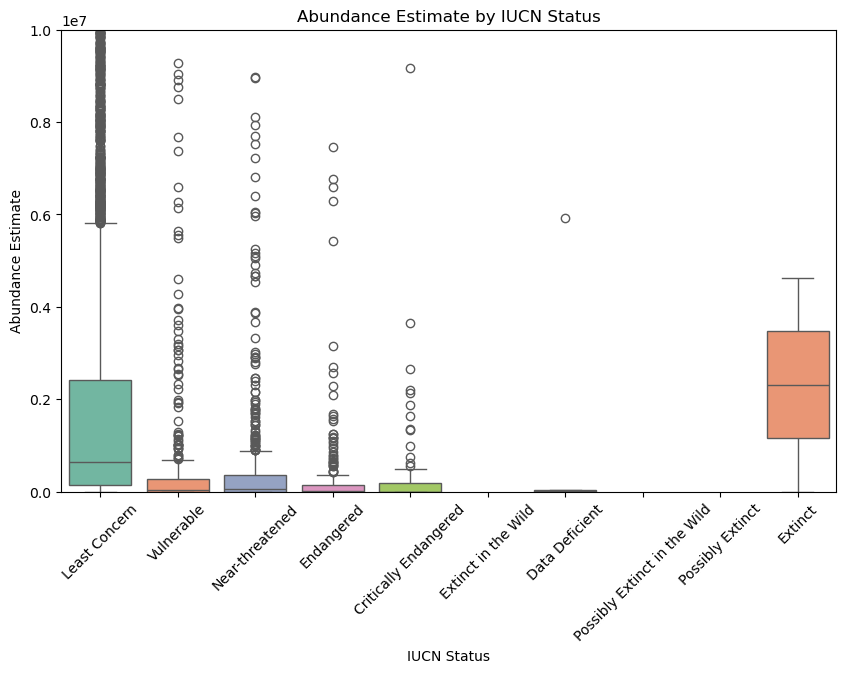

In [104]:
plt.figure(figsize=(10,6))
sns.boxplot(data=merged_complete, x='IUCN_full', y='Abundance estimate', palette='Set2')
plt.xlabel('IUCN Status')
#plt.yscale('log')
plt.ylim(0, 1e7)
plt.ylabel('Abundance Estimate')
plt.title('Abundance Estimate by IUCN Status')
plt.xticks(rotation=45)
plt.savefig("../results/plots/abundance_IUCN.png")
plt.show()

In [106]:
merged_complete[merged_complete['2024 IUCN Red List category']=='EX'][['scientific_name','Abundance estimate','2024 IUCN Red List category']]
# The extinct thing is coming from a 2 data points both of whose close relatives are considered extinct

,scientific_name,Abundance estimate,2024 IUCN Red List category
8575,zosterops conspicillatus,661.0,EX
8583,zosterops albogularis,NaN,EX
9352,turdus poliocephalus,4635607.0,EX
10505,psittirostra psittacea,NaN,EX
10520,hemignathus hanapepe,NaN,EX
10521,hemignathus affinis,NaN,EX
10529,loxops ochraceus,NaN,EX


In [116]:

def plot_pca(merged_df, numeric_cols, cat_col, save_path=None, palette='tab20', figsize=(10,8), point_size=100, order_filter=None):

    df = merged_df.copy()
    if order_filter is not None:
        if isinstance(order_filter, str):
            df = df[df['Order_x'] == order_filter]
        else:  # assume list
            df = df[df['Order_x'].isin(order_filter)]

    
    df_pca_ready = df[numeric_cols].dropna()
    df_complete = df.loc[df_pca_ready.index]
    

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(merged_complete[numeric_cols])
    

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    
    df_pca = pd.DataFrame(pcs, columns=['PC1','PC2'])
    df_pca[cat_col] = merged_complete[cat_col].values

    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=cat_col, palette=palette, s=point_size)
    plt.title('PCA of Selected Traits')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

    loadings = pd.DataFrame(pca.components_.T, columns=['PC1','PC2'], index=numeric_cols)
    
    return df_pca, loadings

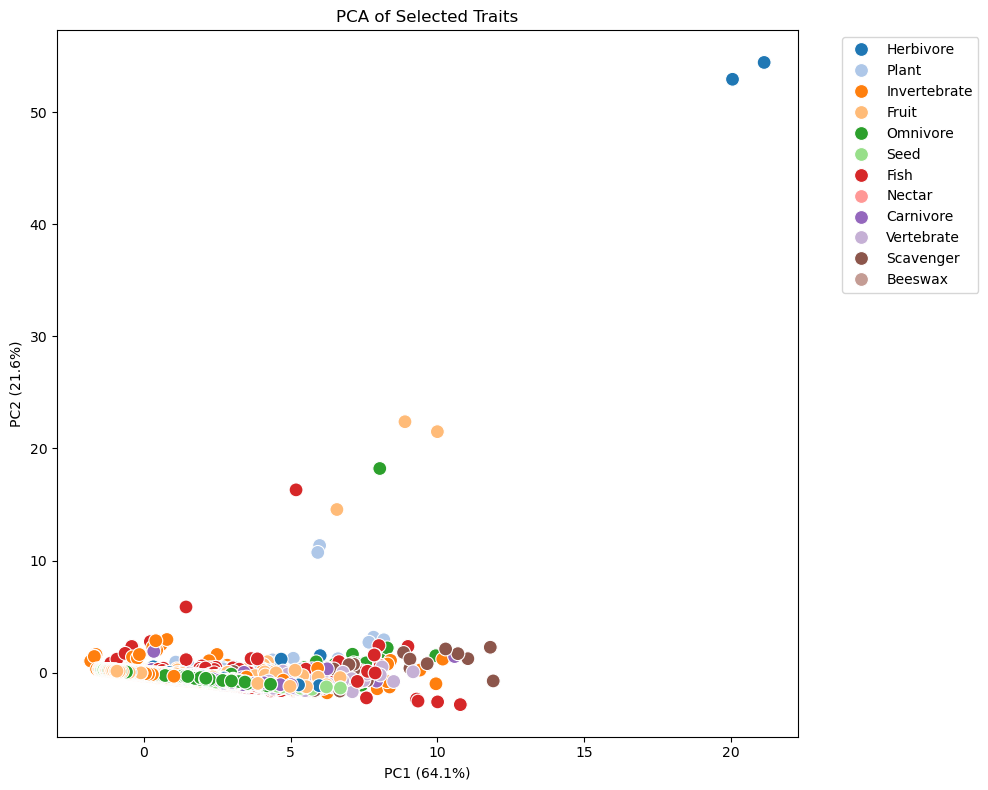

                     PC1       PC2
Wing.Length     0.604914 -0.125426
Mass_combined   0.290277  0.951132
Tail.Length     0.503860 -0.123406
Kipps.Distance  0.544007 -0.253747


In [ ]:
# -----------------------------
# Possible numeric columns:
# Morphology / Body Traits:
# 'Beak.Length_Culmen', 'Beak.Length_Nares', 'Beak.Width', 'Beak.Depth',
# 'Tarsus.Length', 'Wing.Length', 'Kipps.Distance', 'Secondary1', 'Tail.Length'
#
# Mass / Weight:
# 'Mass_combined', 
# 'Female MinMass', 'Female MaxMass', 'Male MinMass',
# 'Male MaxMass', 'Unsexed MinMass', 'Unsexed MaxMass'
# (optionally combined as 'Mass_combined')
#
# Other indices:
# 'ESI', 'Hand-Wing.Index'
#
# Abundance / ecological:
# 'Abundance estimate'
# -----------------------------
# Possible categorical variables:
# 'Order_x', 'Family IOC 15.1', '2024 IUCN Red List category', 'Primary Habitat',
# 'Primary Diet', 'Trophic.Level', 'Trophic.Niche', 'Primary.Lifestyle',
# 'RLM', 'LAT'
# -----------------------------



numeric_cols = ['Wing.Length', 'Mass_combined', 'Tail.Length' , 'Kipps.Distance',  ]
cat_col = 'Primary Diet'
save_path = "../results/plots/pca_beak_diet.png"

df_pca, loadings = plot_pca(merged_complete, numeric_cols, cat_col, save_path=save_path, order_filter='Passeriformes')
print(loadings)

In [137]:
merged_complete[numeric_cols].isna().sum()

Wing.Length         0
Average Mass      663
Tail.Length         0
Kipps.Distance      0
dtype: int64

In [113]:
unique_list = merged['Order_x'].unique().tolist()
unique_list

['Struthioniformes',
 'Rheiformes',
 'Apterygiformes',
 'Casuariiformes',
 'Tinamiformes',
 'Anseriformes',
 'Galliformes',
 'Caprimulgiformes',
 'Musophagiformes',
 'Otidiformes',
 'Cuculiformes',
 'Mesitornithiformes',
 'Pterocliformes',
 'Columbiformes',
 'Gruiformes',
 'Podicipediformes',
 'Phoenicopteriformes',
 'Charadriiformes',
 'Eurypygiformes',
 'Phaethontiformes',
 'Gaviiformes',
 'Sphenisciformes',
 'Procellariiformes',
 'Ciconiiformes',
 'Pelecaniformes',
 'Suliformes',
 'Opisthocomiformes',
 'Cathartiformes',
 'Accipitriformes',
 'Strigiformes',
 'Coliiformes',
 'Leptosomiformes',
 'Trogoniformes',
 'Bucerotiformes',
 'Coraciiformes',
 'Piciformes',
 'Cariamiformes',
 'Falconiformes',
 'Psittaciformes',
 'Passeriformes']

In [125]:
passerines = merged_complete[merged_complete['Order_x'] == 'Passeriformes'].copy()

<Figure size 1000x1000 with 0 Axes>

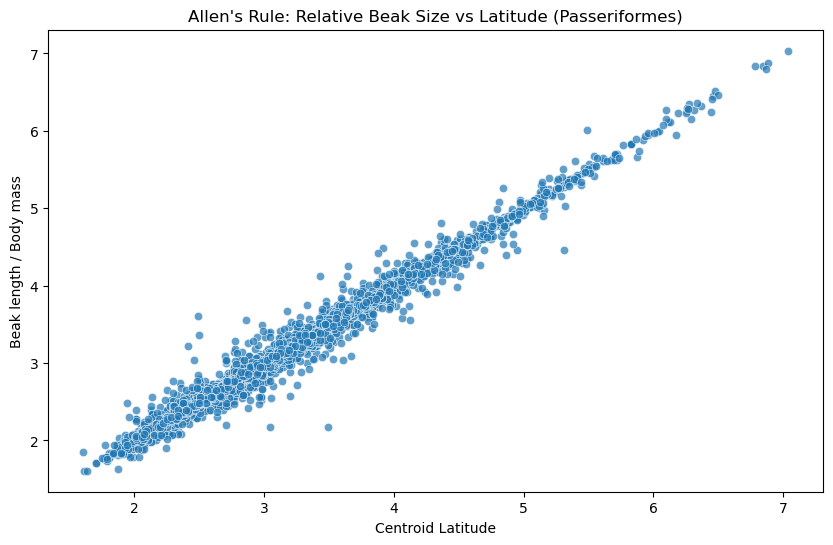

In [131]:
passerines['Beak_to_Mass'] = passerines['Beak.Length_Culmen'] / passerines['Mass_combined']

plt.figure(figsize=(10,10
                    ))

plt.figure(figsize=(10,6))
sns.scatterplot(data=passerines, x='Average Mass', y='Mass', alpha=0.7)
plt.xlabel('Centroid Latitude')
#plt.yscale('log')
plt.ylabel('Beak length / Body mass')
plt.title("Allen's Rule: Relative Beak Size vs Latitude (Passeriformes)")
plt.show()

Trophic.Level  Carnivore  Herbivore  Omnivore  Scavenger
Primary Diet                                            
Beeswax                7          0         0          0
Carnivore            179          0        25          0
Fish                 266          0         0          0
Fruit                  6       1035       227          0
Herbivore              1        363        26          0
Invertebrate        5106         34       576          0
Nectar                 0        439        71          0
Omnivore              75        226       728          0
Plant                  0        134         4          0
Scavenger              0          0         8         20
Seed                   5        718        85          0
Vertebrate           321          0         0          0


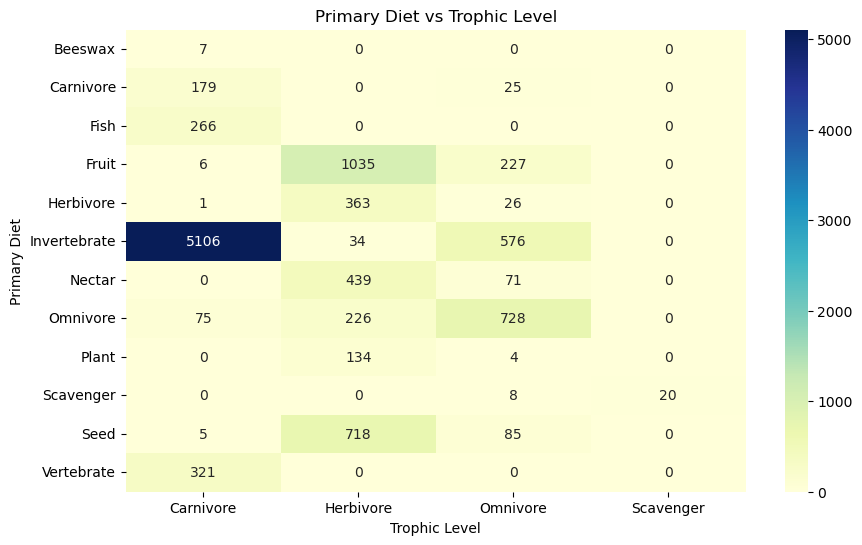

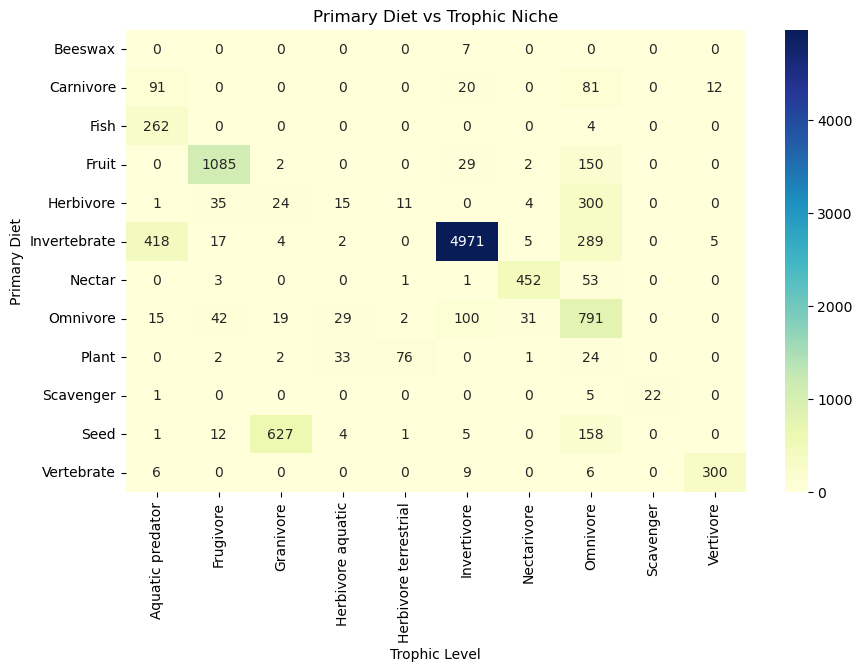

In [141]:
# What is the macth for the trophic level and diet between teh 2 datasets
# Crosstab of Trophic.Level vs Primary Diet
ct = pd.crosstab(merged['Primary Diet'], merged['Trophic.Level'])
print(ct)

# Crosstab of Trophic.Niche vs Primary Diet
ct_niche = pd.crosstab(merged['Primary Diet'], merged['Trophic.Niche'])
#print(ct_niche)


plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Primary Diet vs Trophic Level')
plt.xlabel('Trophic Level')
plt.ylabel('Primary Diet')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(ct_niche, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Primary Diet vs Trophic Niche')
plt.xlabel('Trophic Level')
plt.ylabel('Primary Diet')
plt.show()


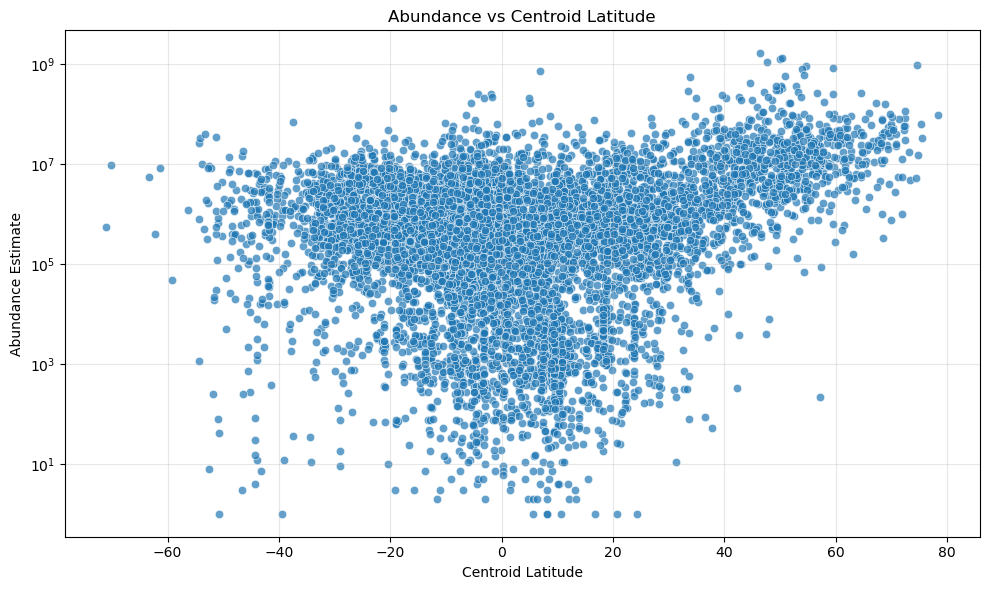

In [ ]:
plt.figure(figsize=(10,6))

# Scatter plot of Abundance vs ESI
sns.scatterplot(data=merged, x='Centroid.Latitude', y='Abundance estimate', alpha=0.7)

plt.xlabel('Centroid Latitude')
plt.ylabel('Abundance Estimate')
plt.title('Abundance vs Centroid Latitude')
plt.yscale('log')  # Optional: abundance varies widely
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [146]:
def plot_numeric_scatter(data, x_var, y_var, color_var=None, figsize=(10,6),
                         alpha=0.7, log_y=False, save_path=None, title=None):

    plt.figure(figsize=figsize)
    
    sns.scatterplot(data=data, x=x_var, y=y_var, hue=color_var, alpha=alpha)
    
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    if title is not None:
        plt.title(title)
    else:
        plt.title(f'{y_var} vs {x_var}')
    
    if log_y:
        plt.yscale('log')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path)
    
    plt.show()

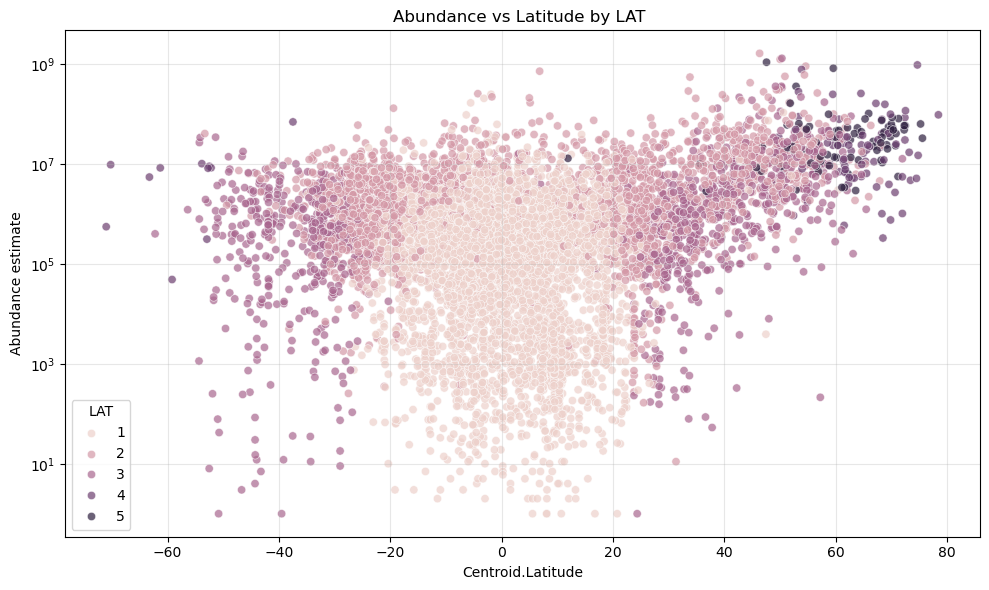

In [151]:
plot_numeric_scatter(merged, 'Centroid.Latitude', 'Abundance estimate',
                     color_var='LAT', log_y=True,
                     title='Abundance vs Latitude by LAT ',
                     save_path='../results/plots/abundance_vs_latitude_LAT.png')

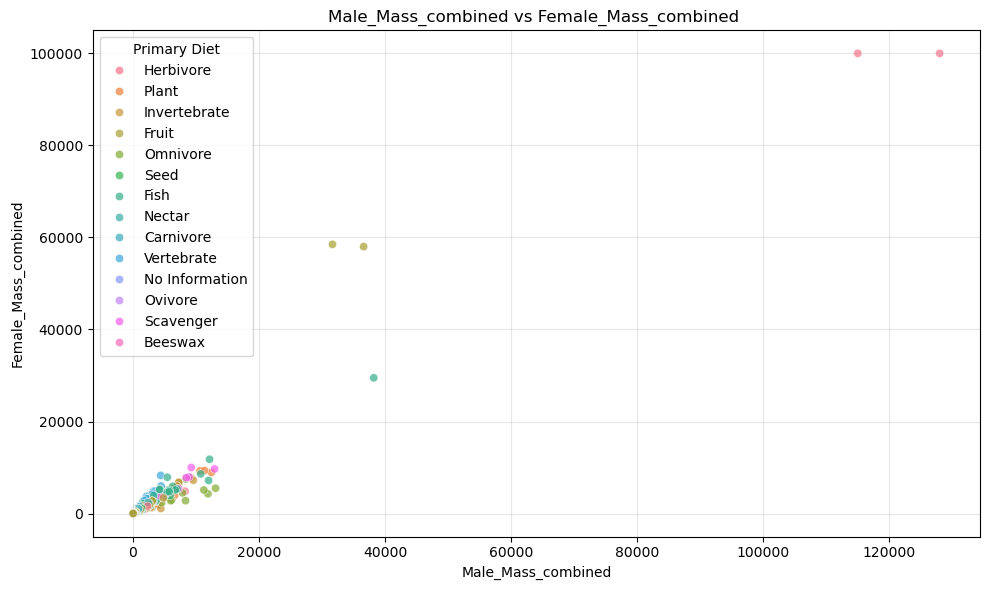

In [173]:
plot_numeric_scatter(merged, 'Male_Mass_combined', 'Female_Mass_combined',
                     color_var='Primary Diet', 
                     #log_y=True,
                     title='Male_Mass_combined vs Female_Mass_combined ',
                     save_path='../results/plots/Male_vs_female_mass.png')

In [161]:
merged_complete.columns.to_list()

['English Name (BirdLife > IOC > Clements>AviList)',
 'scientific_name',
 'Order_x',
 'Family IOC 15.1',
 'Genus',
 'Species',
 '2024 IUCN Red List category',
 'RR',
 'ISL',
 'RLM',
 'LAT',
 'Female MinMass',
 'Female MaxMass',
 'Male MinMass',
 'Male MaxMass',
 'Unsexed MinMass',
 'Unsexed MaxMass',
 'Average Mass',
 'NormMin',
 'Elevational Range',
 'NormMax',
 'F',
 'BM',
 'WD',
 'SH',
 'SV',
 'G',
 'PL',
 'R',
 'D',
 'A',
 'RV',
 'C',
 'W',
 'SE',
 'O',
 'Primary Habitat',
 'HB',
 'Primary Diet',
 'IN-Wt',
 'FR-Wt',
 'NE-Wt',
 'SE-Wt',
 'VE-Wt',
 'FI-Wt',
 'SC-Wt',
 'PL-Wt',
 'MS-Wt',
 'SUM-Wt',
 'DB',
 'ESI',
 'Social_1',
 'Social_2',
 'Social_3',
 'Social_4',
 'Social_5',
 'Social_6',
 'Mono',
 'Poly',
 'Coop',
 'Nest_Type',
 'Nest_SBS',
 'Brd1',
 'Brd2',
 'Clutch_Min',
 'Clutch_Max',
 'Incu_Sex',
 'Incu1',
 'Incu2',
 'Fldg1',
 'Fldg2',
 'Para.1',
 'Para.2',
 'BrS1',
 'BrS2',
 'Prod1',
 'Prod2',
 'Flightlessness',
 'Mig',
 'Alt',
 'Irreg',
 'Disp',
 'Sed',
 'Beak.Length_Culmen',
